In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

n_epochs = 100
import random

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from src.models.temporal_gcn import TemporalGCNModel
from src.dataloading.gnndataloader import GNNDataLoader
from src.dataloading.graphconstructor import GraphConstructor
from src.dataloading.epidataloader import EpiDataLoader

epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(range(1,8))
epidata.preview()


gnnloader1 = GNNDataLoader(epidata).retrieve_graph('gravity_model_kreis_log').construct_dataloaders(periods=16)
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('gravity_model_kreis_minmax').construct_dataloaders(periods=16)
gnnloader3 = GNNDataLoader(epidata).retrieve_graph('identity_graph_kreis').construct_dataloaders(periods=16)

random_ids = [random.randint(0,399) for rr in range(10)]

gravity_model1 = TemporalGCNModel(name = 'gravity model -log', dataloader=gnnloader1)
gravity_model1.set_model_hparams()
gravity_model1.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model1.train()
gravity_model1.forecast()


gravity_model2 = TemporalGCNModel(name = 'gravity model -minmax', dataloader=gnnloader2)
gravity_model2.set_model_hparams()
gravity_model2.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model2.train()
gravity_model2.forecast()
gravity_model2.show_forecasts()

gravity_model3 = TemporalGCNModel(name = 'id graph', dataloader=gnnloader3)
gravity_model3.set_model_hparams()
gravity_model3.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model3.train()
gravity_model3.forecast()
gravity_model3.show_forecasts()


for id in random_ids:
    gravity_model1.show_forecasts(id)
    gravity_model2.show_forecasts(id)    
    gravity_model3.show_forecasts(id)

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


single snapshot: Data(x=[399, 10, 16], edge_index=[2, 41049], y=[399], edge_weight=[41049])


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


single snapshot: Data(x=[399, 6, 16], edge_index=[2, 41049], y=[399], edge_weight=[41049])
Epoch 0 train MSE: 5.5109, val MSE: 13.0432 ✓ (new best)
Epoch 1 train MSE: 5.2782, val MSE: 11.8425 ✓ (new best)
Epoch 2 train MSE: 4.6097, val MSE: 8.5115 ✓ (new best)
Epoch 3 train MSE: 3.8411, val MSE: 6.5648 ✓ (new best)
Epoch 4 train MSE: 3.4403, val MSE: 5.4935 ✓ (new best)
Epoch 5 train MSE: 3.0841, val MSE: 4.5967 ✓ (new best)
Epoch 6 train MSE: 2.8214, val MSE: 3.9214 ✓ (new best)
Epoch 7 train MSE: 2.6337, val MSE: 3.4651 ✓ (new best)
Epoch 8 train MSE: 2.5304, val MSE: 3.1516 ✓ (new best)
Epoch 9 train MSE: 2.4281, val MSE: 2.9484 ✓ (new best)
Test MSE: 3.8758
single snapshot: Data(x=[399, 6, 16], edge_index=[2, 41049], y=[399], edge_weight=[41049])
Epoch 0 train MSE: 5.5489, val MSE: 13.1863 ✓ (new best)
Epoch 1 train MSE: 5.2935, val MSE: 11.7775 ✓ (new best)
Epoch 2 train MSE: 4.5159, val MSE: 8.2339 ✓ (new best)
Epoch 3 train MSE: 3.6754, val MSE: 6.0992 ✓ (new best)
Epoch 4 train

KeyboardInterrupt: 

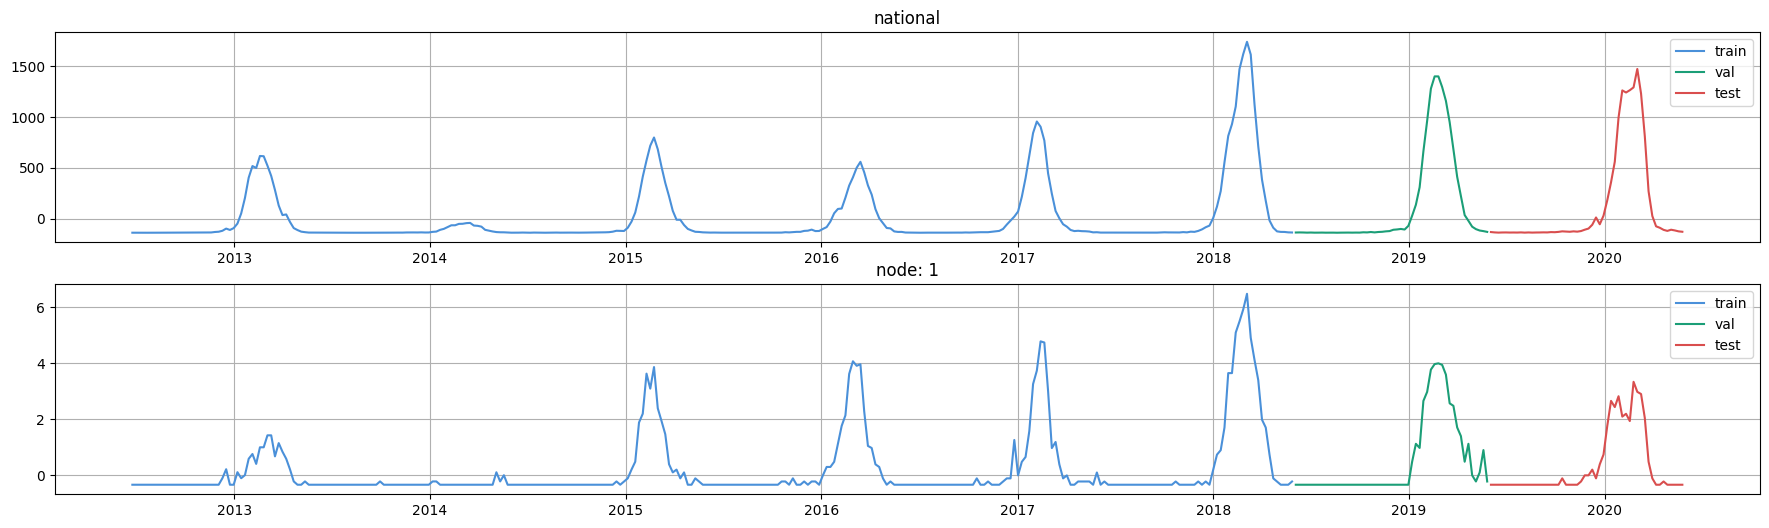

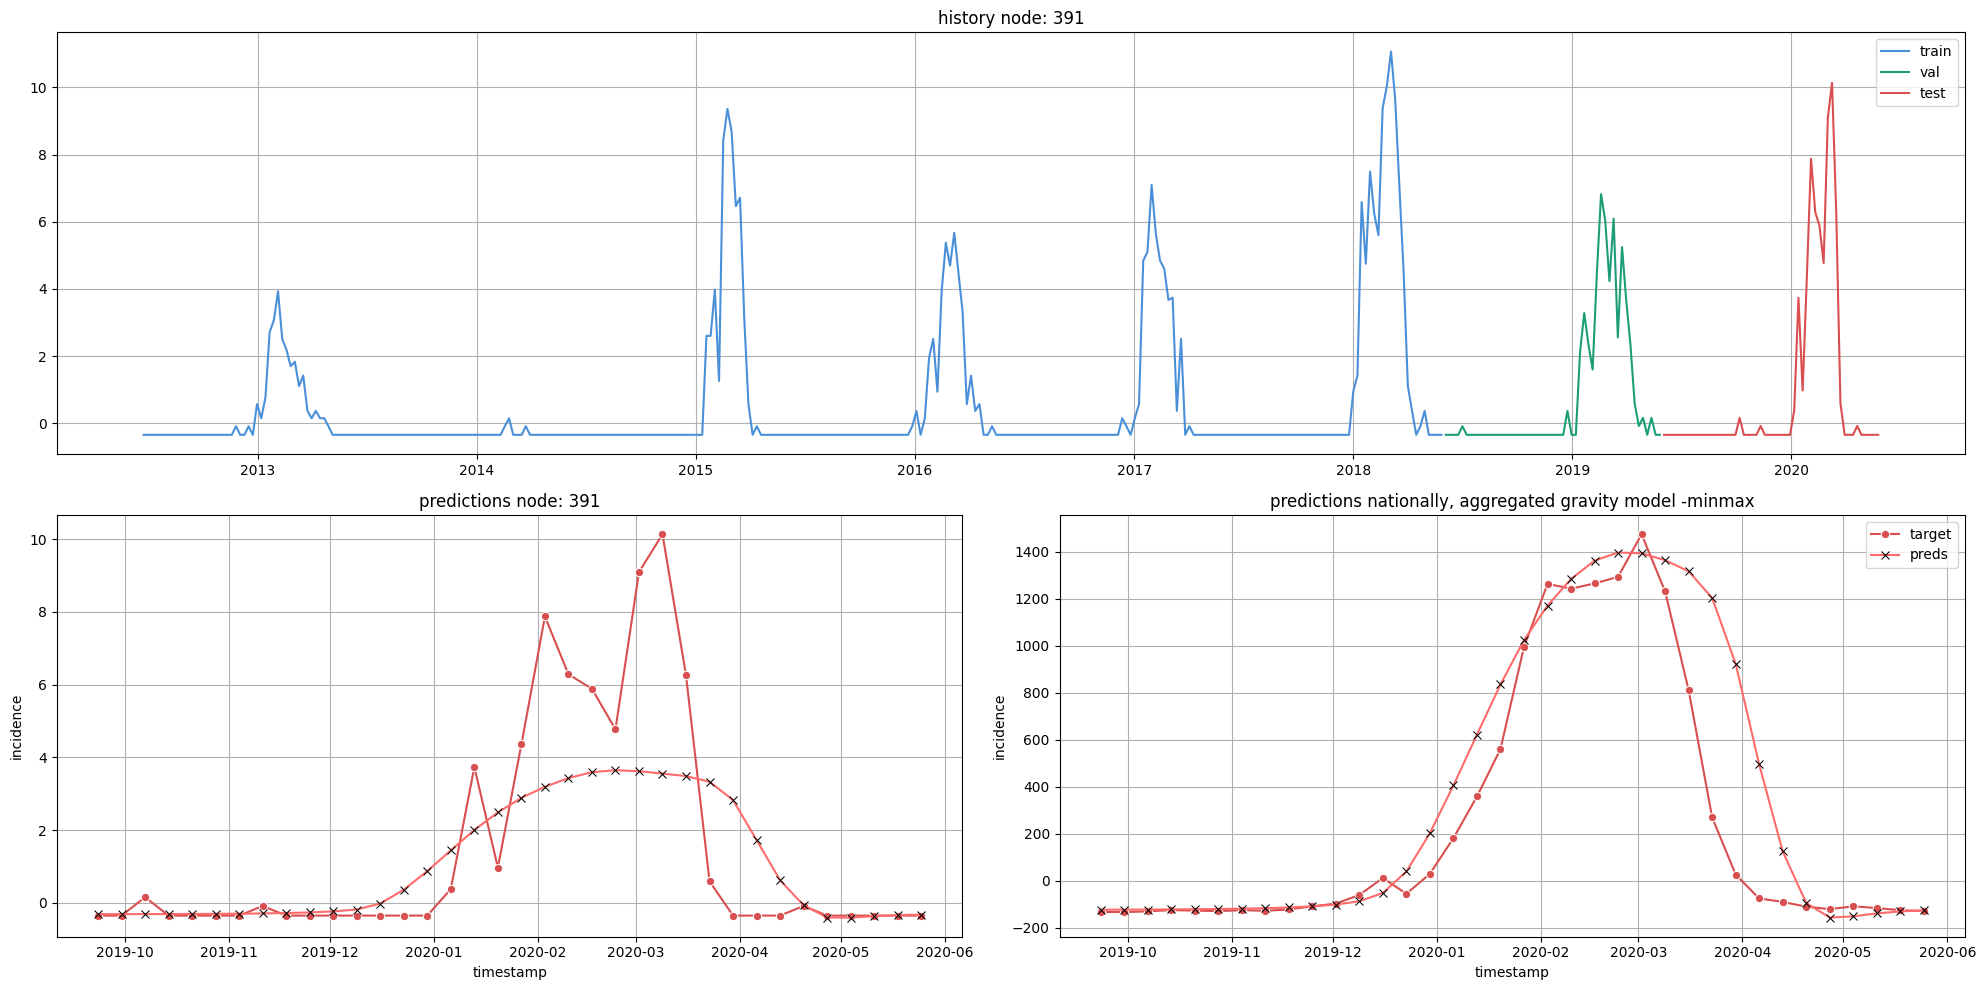

In [ ]:
from src.models.temporal_gcn import TemporalGCNModel
from src.dataloading.gnndataloader import GNNDataLoader
from src.dataloading.graphconstructor import GraphConstructor
from src.dataloading.epidataloader import EpiDataLoader

epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(range(1,4))
epidata.preview()


gnnloader1 = GNNDataLoader(epidata).retrieve_graph('gravity_model_kreis_log').construct_dataloaders(periods=16)
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('gravity_model_kreis_minmax').construct_dataloaders(periods=16)
gnnloader3 = GNNDataLoader(epidata).retrieve_graph('identity_graph_kreis').construct_dataloaders(periods=16)

random_ids = [random.randint(0,399) for rr in range(10)]

gravity_model1 = TemporalGCNModel(name = 'gravity model -log', dataloader=gnnloader1)
gravity_model1.set_model_hparams()
gravity_model1.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model1.train()
gravity_model1.forecast()


gravity_model2 = TemporalGCNModel(name = 'gravity model -minmax', dataloader=gnnloader2)
gravity_model2.set_model_hparams()
gravity_model2.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model2.train()
gravity_model2.forecast()
gravity_model2.show_forecasts()

gravity_model3 = TemporalGCNModel(name = 'id graph', dataloader=gnnloader3)
gravity_model3.set_model_hparams()
gravity_model3.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model3.train()
gravity_model3.forecast()
gravity_model3.show_forecasts()


for id in random_ids:
    gravity_model1.show_forecasts(id)
    gravity_model2.show_forecasts(id)    
    gravity_model3.show_forecasts(id)

In [ ]:
from src.models.temporal_gcn import TemporalGCNModel
from src.dataloading.gnndataloader import GNNDataLoader
from src.dataloading.graphconstructor import GraphConstructor
from src.dataloading.epidataloader import EpiDataLoader

epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(range(2,6))
epidata.preview()


gnnloader1 = GNNDataLoader(epidata).retrieve_graph('gravity_model_kreis_log').construct_dataloaders(periods=16)
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('gravity_model_kreis_minmax').construct_dataloaders(periods=16)
gnnloader3 = GNNDataLoader(epidata).retrieve_graph('identity_graph_kreis').construct_dataloaders(periods=16)

random_ids = [random.randint(0,399) for rr in range(10)]

gravity_model1 = TemporalGCNModel(name = 'gravity model -log', dataloader=gnnloader1)
gravity_model1.set_model_hparams()
gravity_model1.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model1.train()
gravity_model1.forecast()


gravity_model2 = TemporalGCNModel(name = 'gravity model -minmax', dataloader=gnnloader2)
gravity_model2.set_model_hparams()
gravity_model2.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model2.train()
gravity_model2.forecast()
gravity_model2.show_forecasts()

gravity_model3 = TemporalGCNModel(name = 'id graph', dataloader=gnnloader3)
gravity_model3.set_model_hparams()
gravity_model3.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model3.train()
gravity_model3.forecast()
gravity_model3.show_forecasts()


for id in random_ids:
    gravity_model1.show_forecasts(id)
    gravity_model2.show_forecasts(id)    
    gravity_model3.show_forecasts(id)